# Laboratorio 02: pandas y series de tiempo EUR/USD

**Objetivo.** Explorar la serie horaria EUR/USD, estudiar los cambios del precio de cierre y resumir los datos de 2023.

**Fuente.** [CSV histórico EUR/USD](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv).

In [29]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

URL = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv'
raw_df = pd.read_csv(URL)

# El CSV puede incluir un índice exportado; se elimina sin asumir que siempre exista.
raw_df = raw_df.loc[:, ~raw_df.columns.str.match(r'^Unnamed(?::.*)?$')]
raw_df['time'] = pd.to_datetime(raw_df['time'], errors='raise')
raw_df = raw_df.sort_values('time').set_index('time')
raw_df.index.name = 'Time'

print('Primeras filas:')
display(raw_df.head())
print('Información:')
raw_df.info()
print(f'Forma: {raw_df.shape}')
print('Tipos de datos:')
display(raw_df.dtypes.to_frame('Tipo'))
print(f'Rango de fechas: {raw_df.index.min()} a {raw_df.index.max()}')
print('Valores nulos por columna:')
display(raw_df.isna().sum().to_frame('Nulos'))

Primeras filas:


,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
Time,,,,,,,,,,,
2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


Información:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                5000 non-null   float64
 1   high                5000 non-null   float64
 2   low                 5000 non-null   float64
 3   close               5000 non-null   float64
 4   tick_volume         5000 non-null   int64  
 5   spread              5000 non-null   int64  
 6   real_volume         5000 non-null   int64  
 7   MeanCloseOpen       5000 non-null   float64
 8   Diff_Close          5000 non-null   float64
 9   Diff_Open           5000 non-null   float64
 10  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 468.8 KB
Forma: (5000, 11)
Tipos de datos:


,Tipo
open,float64
high,float64
low,float64
close,float64
tick_volume,int64
spread,int64
real_volume,int64
MeanCloseOpen,float64
Diff_Close,float64
Diff_Open,float64


Rango de fechas: 2022-07-25 13:00:00 a 2023-05-12 23:00:00
Valores nulos por columna:


,Nulos
open,0
high,0
low,0
close,0
tick_volume,0
spread,0
real_volume,0
MeanCloseOpen,0
Diff_Close,0
Diff_Open,0


Columnas finales: ['Close', 'DiffPrice']
Índice temporal: True | nombre: Time


,Close,DiffPrice
Time,,
2022-07-25 13:00:00,1.02345,NaN
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304


La primera diferencia es NaN porque no hay una hora previa para la primera observación; se excluye al ajustar y graficar.


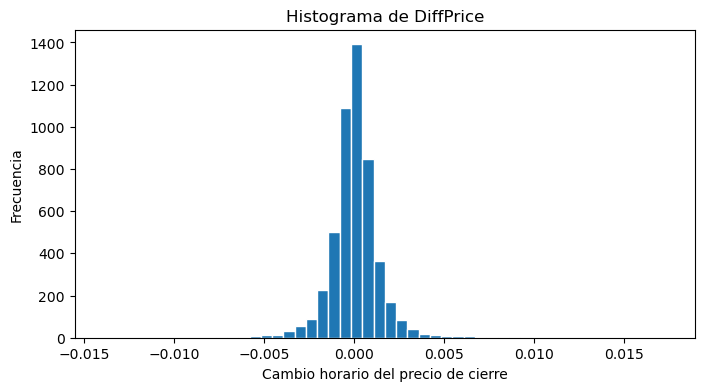

In [30]:
def pascal_case(name):
    return ''.join(part.capitalize() for part in name.replace('-', '_').split('_'))

raw_df.columns = [pascal_case(column) for column in raw_df.columns]
df = raw_df[['Close']].copy()
df['DiffPrice'] = df['Close'].diff()

print('Columnas finales:', df.columns.tolist())
print('Índice temporal:', isinstance(df.index, pd.DatetimeIndex), '| nombre:', df.index.name)
display(df.head())
print('La primera diferencia es NaN porque no hay una hora previa para la primera observación; se excluye al ajustar y graficar.')
diff_price = df['DiffPrice'].dropna()

plt.figure(figsize=(8, 4))
plt.hist(diff_price, bins=50, edgecolor='white')
plt.title('Histograma de DiffPrice')
plt.xlabel('Cambio horario del precio de cierre')
plt.ylabel('Frecuencia')
plt.show()

In [31]:
from fitter import Fitter, get_common_distributions, get_distributions

Para encontrar el mejor fit, se uso el "Fitter" con todas la s distribuciones de "get_distributions" y se identifico la mejor distribucion con el metodo "sumsquare_error". Se muestran algunas de las dristribuciones que se probaron, como "norm", "genhyperbolic", "norminvgauss", "cauchy" y "johnsonsu". La mejor distribucion encontrada fue la "johnsonsu" con sus parametros ajustados.

2026-09-03 23:52:35.784 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=106744.023571, AIC=-51505.72, KS=0.0905
2026-09-03 23:52:35.818 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=23122.545603, AIC=-52492.69, KS=0.0425
2026-09-03 23:52:35.973 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted johnsonsu: error=1660.385337, AIC=-53160.70, KS=0.0110
2026-09-03 23:52:42.307 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted genhyperbolic: error=1821.497871, AIC=-53157.86, KS=0.0117
2026-09-03 23:52:43.416 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norminvgauss: error=1938.681101, AIC=-53153.22, KS=0.0099


{'johnsonsu': {'a': np.float64(-0.020654532350683215),
  'b': np.float64(1.049797421216857),
  'loc': np.float64(-1.5194909287993722e-05),
  'scale': np.float64(0.0008808828671326262)}}

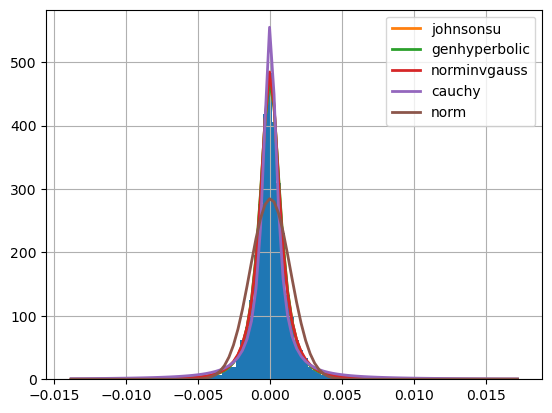

In [32]:
f = Fitter(diff_price, distributions=['norm',
                                      'genhyperbolic',
                                      'norminvgauss',
                                      'cauchy',
                                      'johnsonsu'])
f.fit()
f.summary()
# identificar la mejor
f.get_best(method='sumsquare_error')

In [33]:
parameters = f.fitted_param["johnsonsu"]
parameters

(np.float64(-0.020654532350683215),
 np.float64(1.049797421216857),
 np.float64(-1.5194909287993722e-05),
 np.float64(0.0008808828671326262))

In [34]:
df_2023 = df.loc['2023'].copy()
print(f'Observaciones de 2023: {df_2023.shape[0]}')
display(df_2023.head())

print('Promedio cada 15 días:')
display(df_2023.resample('15D').mean())
print('Promedio semanal:')
display(df_2023.resample('W').mean())
print('Promedio mensual:')
display(df_2023.resample('ME').mean())

Observaciones de 2023: 2278


,Close,DiffPrice
Time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016


Promedio cada 15 días:


,Close,DiffPrice
Time,,
2023-01-02,1.069361,0.000047
2023-01-17,1.085565,0.000015
2023-02-01,1.077679,-0.000066
2023-02-16,1.063150,-0.000034
2023-03-03,1.063186,0.000026
2023-03-18,1.080936,0.000074
2023-04-02,1.093090,0.000063
2023-04-17,1.099084,-0.000006
2023-05-02,1.098889,-0.000059


Promedio semanal:


,Close,DiffPrice
Time,,
2023-01-08,1.059972,-0.000047
2023-01-15,1.076002,0.000156
2023-01-22,1.082041,0.000020
2023-01-29,1.088414,0.000010
2023-02-05,1.089281,-0.000062
2023-02-12,1.073363,-0.000097
2023-02-19,1.069648,0.000014
2023-02-26,1.063374,-0.000124
2023-03-05,1.060854,0.000073


Promedio mensual:


,Close,DiffPrice
Time,,
2023-01-31,1.077463,0.000031
2023-02-28,1.071167,-0.000060
2023-03-31,1.070874,0.000049
2023-04-30,1.096051,0.000036
2023-05-31,1.098980,-0.000069


Meses disponibles en 2023: [1, 2, 3, 4, 5]
Meses sin datos en 2023: [6, 7, 8, 9, 10, 11, 12]


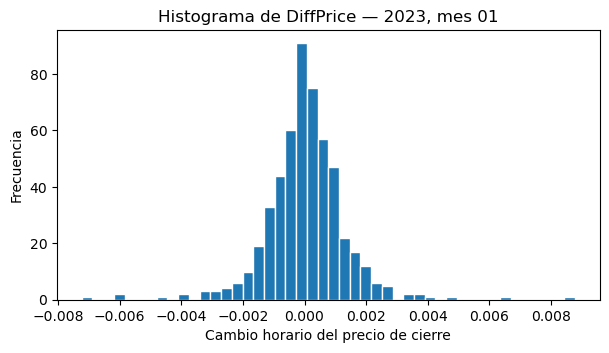

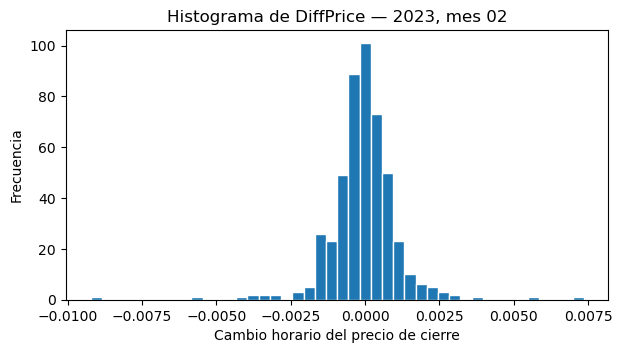

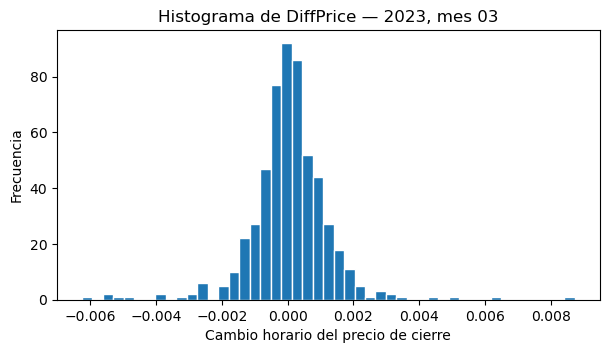

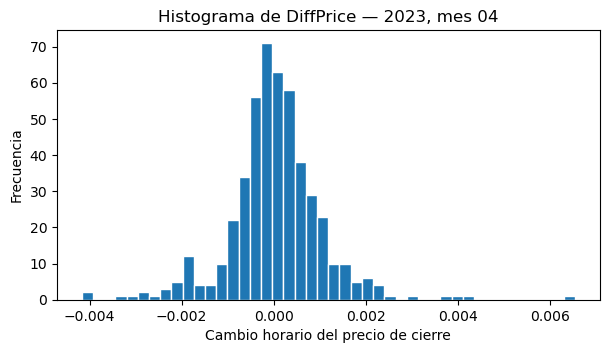

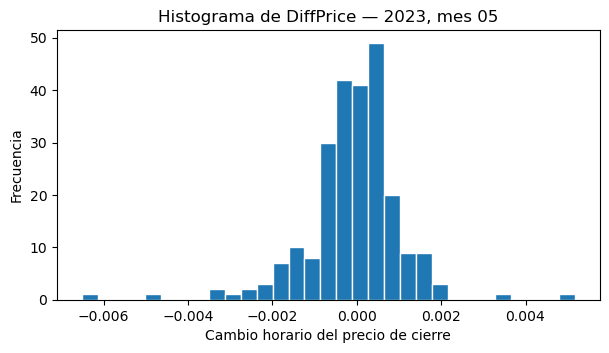

In [35]:
meses_presentes = sorted(df_2023.index.month.unique())
meses_faltantes = [mes for mes in range(1, 13) if mes not in meses_presentes]
print('Meses disponibles en 2023:', meses_presentes)
print('Meses sin datos en 2023:', meses_faltantes)

for mes, grupo in df_2023.groupby(df_2023.index.month):
    datos_mes = grupo['DiffPrice'].dropna()
    plt.figure(figsize=(7, 3.5))
    plt.hist(datos_mes, bins="auto", edgecolor='white')
    plt.title(f'Histograma de DiffPrice — 2023, mes {mes:02d}')
    plt.xlabel('Cambio horario del precio de cierre')
    plt.ylabel('Frecuencia')
    plt.show()

# Parte B: análisis del conjunto WDBC

Se usa el conjunto **Breast Cancer Wisconsin (Diagnostic), WDBC** de UCI, desde su archivo crudo estable `wdbc.data`. Contiene 569 filas: `ID`, `Diagnosis` y 30 mediciones continuas. La referencia `target` del enunciado se cumple con `Diagnosis`, que conserva B (benigno) y M (maligno). Las mediciones son Radius, Texture, Perimeter, Area, Smoothness, Compactness, Concavity, ConcavePoints, Symmetry y FractalDimension, cada una con media, error estándar y peor valor.

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

WDBC_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'
families = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness', 'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']
measurements = [f'{family}{suffix}' for suffix in ['Mean', 'Se', 'Worst'] for family in families]
wdbc_df = pd.read_csv(WDBC_URL, header=None, names=['ID', 'Diagnosis', *measurements])
wdbc_df['DiagnosisNumeric'] = wdbc_df['Diagnosis'].map({'B': 0, 'M': 1})
assert wdbc_df.shape == (569, 33) and len(measurements) == 30
print(f'Fuente: {WDBC_URL}')
print(f'Forma: {wdbc_df.shape}; 30 mediciones continuas; columnas en PascalCase.')
print('Diagnosis es el campo legible B/M referido como target; DiagnosisNumeric usa B=0 y M=1.')

Fuente: https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data
Forma: (569, 33); 30 mediciones continuas; columnas en PascalCase.
Diagnosis es el campo legible B/M referido como target; DiagnosisNumeric usa B=0 y M=1.


In [37]:
print('head()'); display(wdbc_df.head())
print('tail()'); display(wdbc_df.tail())
print('describe() de las variables continuas'); display(wdbc_df[measurements].describe())
print('info()'); wdbc_df.info()
print('Valores nulos por columna:'); display(wdbc_df.isna().sum().to_frame('Nulos'))
if wdbc_df.isna().any().any():
    print('Estrategia: imputar la mediana en mediciones y la moda en Diagnosis.')
else:
    print('No hay valores nulos; no se requiere imputación. Si los hubiera, se usarían mediana y moda, respectivamente.')

head()


,ID,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst,DiagnosisNumeric
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


tail()


,ID,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst,DiagnosisNumeric
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,0


describe() de las variables continuas


,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     569 non-null    int64  
 1   Diagnosis              569 non-null    object 
 2   RadiusMean             569 non-null    float64
 3   TextureMean            569 non-null    float64
 4   PerimeterMean          569 non-null    float64
 5   AreaMean               569 non-null    float64
 6   SmoothnessMean         569 non-null    float64
 7   CompactnessMean        569 non-null    float64
 8   ConcavityMean          569 non-null    float64
 9   ConcavePointsMean      569 non-null    float64
 10  SymmetryMean           569 non-null    float64
 11  FractalDimensionMean   569 non-null    float64
 12  RadiusSe               569 non-null    float64
 13  TextureSe              569 non-null    float64
 14  PerimeterSe            569 non-null    float64
 15 

,Nulos
ID,0
Diagnosis,0
RadiusMean,0
TextureMean,0
PerimeterMean,0
AreaMean,0
SmoothnessMean,0
CompactnessMean,0
ConcavityMean,0
ConcavePointsMean,0


No hay valores nulos; no se requiere imputación. Si los hubiera, se usarían mediana y moda, respectivamente.


Valores únicos de Diagnosis: ['M' 'B']


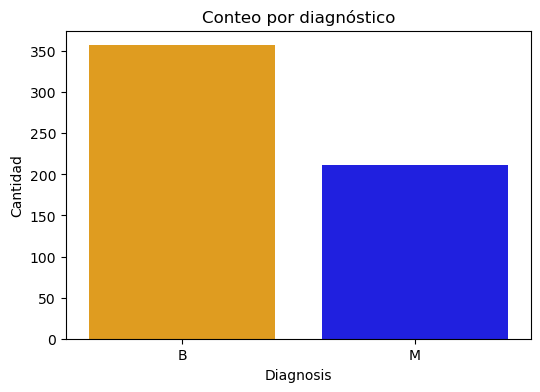

Solo las 30 mediciones fueron estandarizadas con (x - media) / desviación estándar; ID y etiquetas no se escalaron.
Máximo |promedio|: 8.37e-16; rango de desviación estándar: 1.000000–1.000000


,mean,std
RadiusMean,-0.0,1.0
TextureMean,0.0,1.0
PerimeterMean,-0.0,1.0
AreaMean,-0.0,1.0
SmoothnessMean,-0.0,1.0
CompactnessMean,0.0,1.0
ConcavityMean,0.0,1.0
ConcavePointsMean,-0.0,1.0
SymmetryMean,0.0,1.0
FractalDimensionMean,0.0,1.0


In [38]:
print('Valores únicos de Diagnosis:', wdbc_df['Diagnosis'].unique())
plt.figure(figsize=(6, 4))
sns.countplot(data=wdbc_df, x='Diagnosis', order=['B', 'M'], hue='Diagnosis', palette={'B': 'orange', 'M': 'blue'}, legend=False)
plt.title('Conteo por diagnóstico'); plt.ylabel('Cantidad'); plt.show()

wdbc_standardized = wdbc_df.copy()
wdbc_standardized[measurements] = (wdbc_df[measurements] - wdbc_df[measurements].mean()) / wdbc_df[measurements].std()
verification = wdbc_standardized[measurements].agg(['mean', 'std']).T
print('Solo las 30 mediciones fueron estandarizadas con (x - media) / desviación estándar; ID y etiquetas no se escalaron.')
print(f"Máximo |promedio|: {verification['mean'].abs().max():.2e}; rango de desviación estándar: {verification['std'].min():.6f}–{verification['std'].max():.6f}")
display(verification.head(10).round(6))

Grupos explícitos: {'Mean': 10, 'Se': 10, 'Worst': 10}
Promedios de cada familia sobre Mean, Se y Worst:


,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,ConcavePoints,Symmetry,FractalDimension
0,1.822892,-1.331460,2.133644,1.822793,0.886604,2.403566,1.827201,1.828182,2.037172,1.698454
1,1.377122,-0.532558,1.160448,1.512536,-0.602112,-0.536342,-0.203612,0.631241,-0.349009,-0.228767
2,1.438879,-0.115855,1.253866,1.397605,0.390527,0.982746,0.809797,1.804099,0.775643,0.032286
3,-0.241121,0.092354,-0.185181,-0.533818,2.453684,3.343920,1.573617,1.579444,4.544703,3.960995
4,1.438539,-1.135278,1.461481,1.411195,0.660750,0.059090,0.936729,1.099685,-0.412639,-0.153272


Aliases equivalentes solicitados:


,SymmetryWorst,Symmetry3,FractalDimensionWorst,FractalDimension3
0,0.4601,0.4601,0.11890,0.11890
1,0.2750,0.2750,0.08902,0.08902
2,0.3613,0.3613,0.08758,0.08758
3,0.6638,0.6638,0.17300,0.17300
4,0.2364,0.2364,0.07678,0.07678


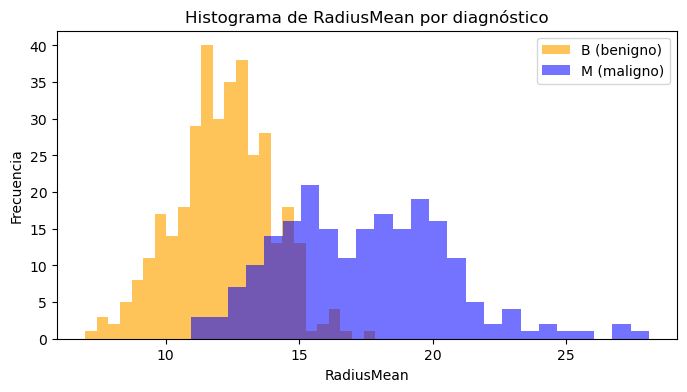

In [39]:
# _mean, _error y _worst se mapearon a los sufijos PascalCase Mean, Se y Worst.
suffix_groups = {suffix: [f'{family}{suffix}' for family in families] for suffix in ['Mean', 'Se', 'Worst']}
family_groups = {family: [f'{family}{suffix}' for suffix in ['Mean', 'Se', 'Worst']] for family in families}
family_averages = pd.DataFrame({family: wdbc_standardized[group].mean(axis=1) for family, group in family_groups.items()})
wdbc_df['Symmetry3'] = wdbc_df['SymmetryWorst']
wdbc_df['FractalDimension3'] = wdbc_df['FractalDimensionWorst']
print('Grupos explícitos:', {name: len(group) for name, group in suffix_groups.items()})
print('Promedios de cada familia sobre Mean, Se y Worst:'); display(family_averages.head())
print('Aliases equivalentes solicitados:'); display(wdbc_df[['SymmetryWorst', 'Symmetry3', 'FractalDimensionWorst', 'FractalDimension3']].head())

plt.figure(figsize=(8, 4))
plt.hist(wdbc_df.loc[wdbc_df['Diagnosis'] == 'B', 'RadiusMean'], bins=25, color='orange', alpha=0.65, label='B (benigno)')
plt.hist(wdbc_df.loc[wdbc_df['Diagnosis'] == 'M', 'RadiusMean'], bins=25, color='blue', alpha=0.55, label='M (maligno)')
plt.title('Histograma de RadiusMean por diagnóstico'); plt.xlabel('RadiusMean'); plt.ylabel('Frecuencia'); plt.legend(); plt.show()

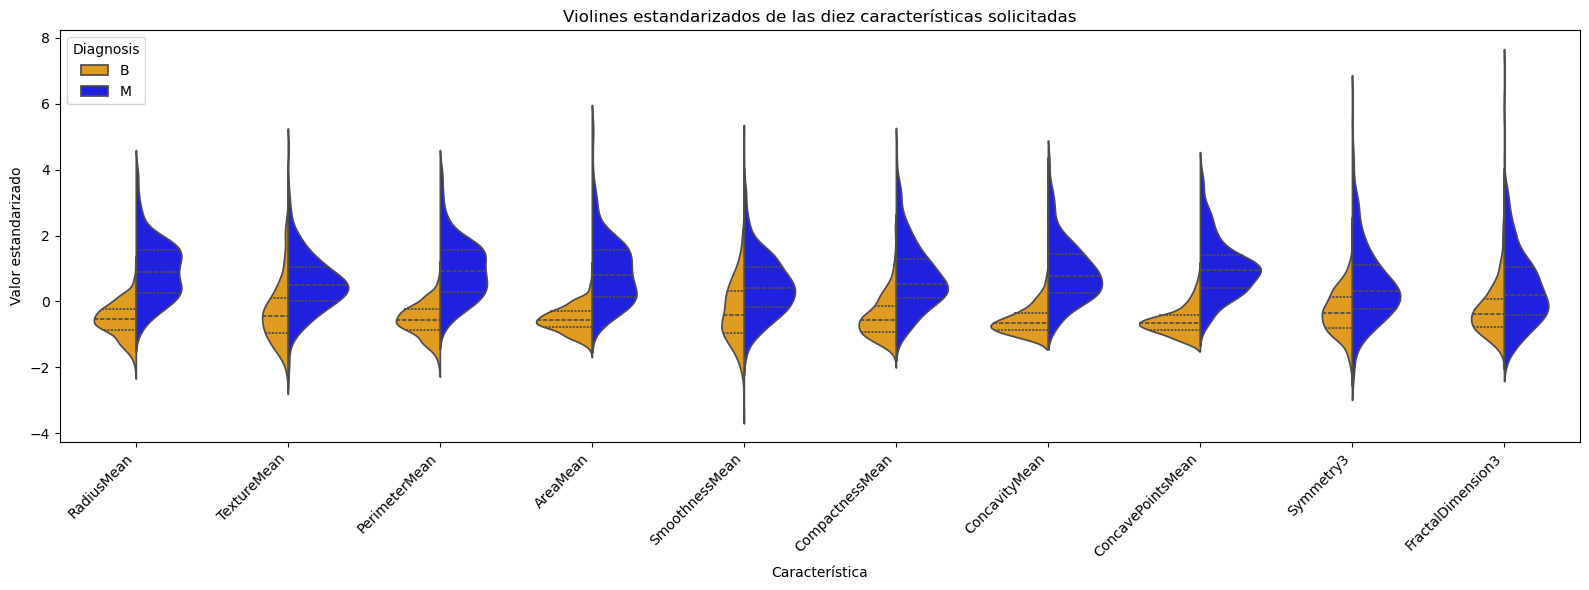

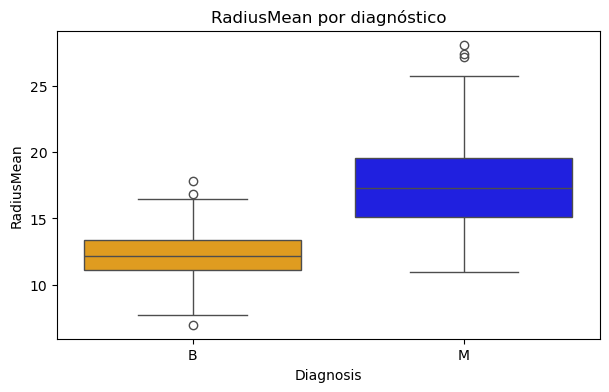

IQR: 4.080; límites: [5.580, 21.900]; outliers: 14
Filas antes: 569; después en wdbc_radius_iqr_cleaned: 555
Los valores se excluyen solo de wdbc_radius_iqr_cleaned; el DataFrame original no se modifica.


In [40]:
violin_features = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'Symmetry3', 'FractalDimension3']
# Se estandariza solo esta copia para comparar variables con escalas distintas.
violin_scaled = wdbc_df[violin_features].copy()
violin_scaled = (violin_scaled - violin_scaled.mean()) / violin_scaled.std()
violin_scaled['Diagnosis'] = wdbc_df['Diagnosis']
violin_data = pd.melt(violin_scaled, id_vars='Diagnosis', var_name='Feature', value_name='Value')
plt.figure(figsize=(16, 6))
sns.violinplot(data=violin_data, x='Feature', y='Value', hue='Diagnosis', hue_order=['B', 'M'], split=True, inner='quart', palette={'B': 'orange', 'M': 'blue'})
plt.title('Violines estandarizados de las diez características solicitadas'); plt.xlabel('Característica'); plt.ylabel('Valor estandarizado'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=wdbc_df, x='Diagnosis', y='RadiusMean', order=['B', 'M'], hue='Diagnosis', palette={'B': 'orange', 'M': 'blue'}, legend=False)
plt.title('RadiusMean por diagnóstico'); plt.show()
q1, q3 = wdbc_df['RadiusMean'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
radius_outliers = (wdbc_df['RadiusMean'] < lower) | (wdbc_df['RadiusMean'] > upper)
wdbc_radius_iqr_cleaned = wdbc_df.loc[~radius_outliers].copy()
print(f'IQR: {iqr:.3f}; límites: [{lower:.3f}, {upper:.3f}]; outliers: {radius_outliers.sum()}')
print(f'Filas antes: {len(wdbc_df)}; después en wdbc_radius_iqr_cleaned: {len(wdbc_radius_iqr_cleaned)}')
print('Los valores se excluyen solo de wdbc_radius_iqr_cleaned; el DataFrame original no se modifica.')

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
RadiusMean,1.00,0.32,1.00,0.99,0.17,0.51,0.68,0.82,0.15,-0.31,...,0.97,0.30,0.97,0.94,0.12,0.41,0.53,0.74,0.16,0.01
TextureMean,0.32,1.00,0.33,0.32,-0.02,0.24,0.30,0.29,0.07,-0.08,...,0.35,0.91,0.36,0.34,0.08,0.28,0.30,0.30,0.11,0.12
PerimeterMean,1.00,0.33,1.00,0.99,0.21,0.56,0.72,0.85,0.18,-0.26,...,0.97,0.30,0.97,0.94,0.15,0.46,0.56,0.77,0.19,0.05
AreaMean,0.99,0.32,0.99,1.00,0.18,0.50,0.69,0.82,0.15,-0.28,...,0.96,0.29,0.96,0.96,0.12,0.39,0.51,0.72,0.14,0.00
SmoothnessMean,0.17,-0.02,0.21,0.18,1.00,0.66,0.52,0.55,0.56,0.58,...,0.21,0.04,0.24,0.21,0.81,0.47,0.43,0.50,0.39,0.50
CompactnessMean,0.51,0.24,0.56,0.50,0.66,1.00,0.88,0.83,0.60,0.57,...,0.54,0.25,0.59,0.51,0.57,0.87,0.82,0.82,0.51,0.69
ConcavityMean,0.68,0.30,0.72,0.69,0.52,0.88,1.00,0.92,0.50,0.34,...,0.69,0.30,0.73,0.68,0.45,0.75,0.88,0.86,0.41,0.51
ConcavePointsMean,0.82,0.29,0.85,0.82,0.55,0.83,0.92,1.00,0.46,0.17,...,0.83,0.29,0.86,0.81,0.45,0.67,0.75,0.91,0.38,0.37
SymmetryMean,0.15,0.07,0.18,0.15,0.56,0.60,0.50,0.46,1.00,0.48,...,0.19,0.09,0.22,0.18,0.43,0.47,0.43,0.43,0.70,0.44
FractalDimensionMean,-0.31,-0.08,-0.26,-0.28,0.58,0.57,0.34,0.17,0.48,1.00,...,-0.25,-0.05,-0.21,-0.23,0.50,0.46,0.35,0.18,0.33,0.77


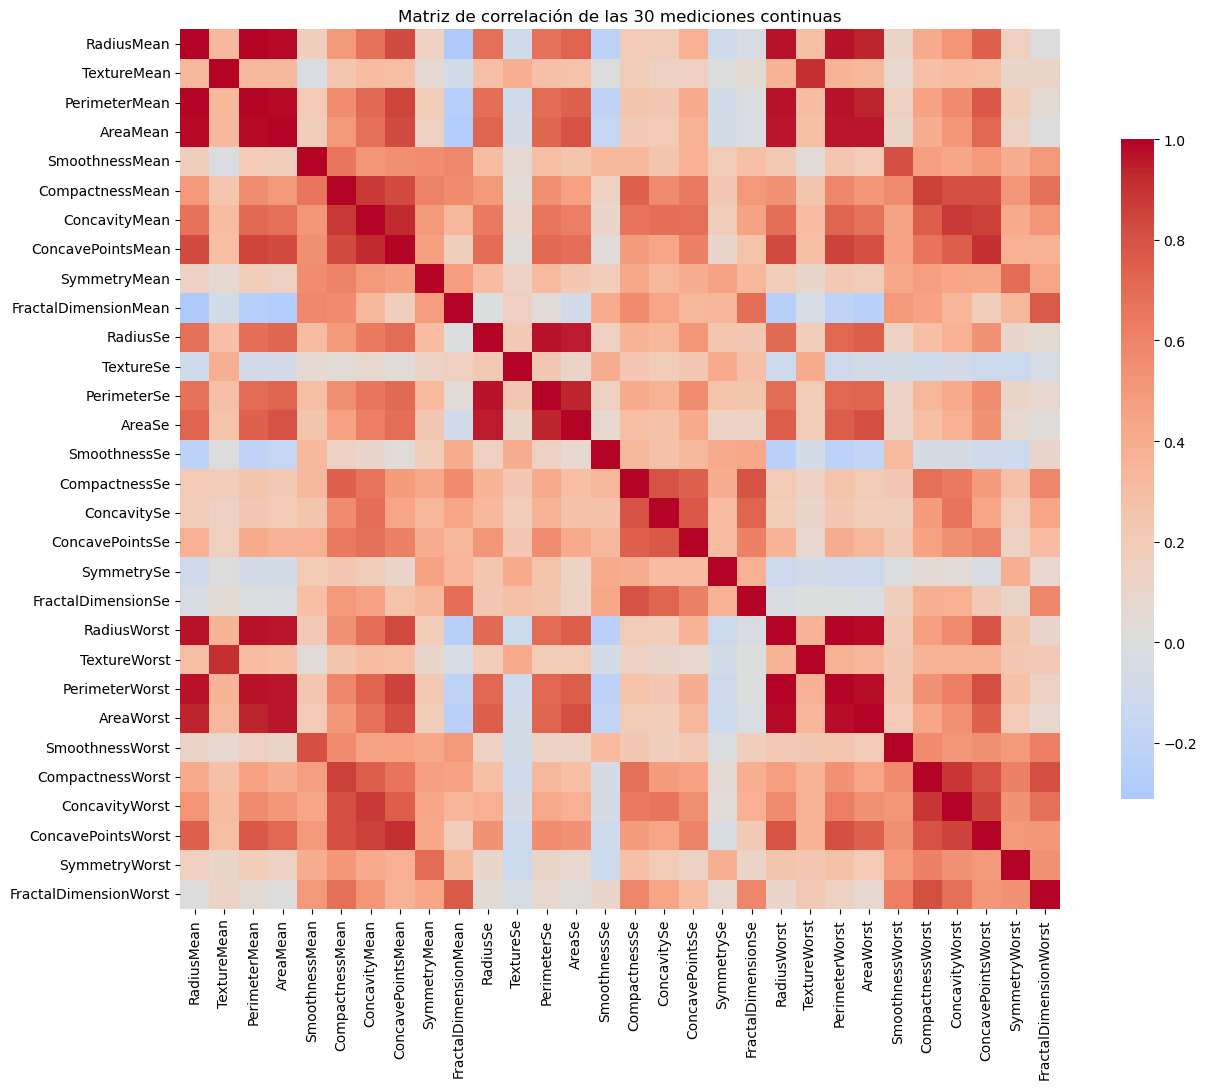

In [41]:
correlation_matrix = wdbc_df[measurements].corr()
display(correlation_matrix.round(2))
plt.figure(figsize=(14, 11))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.75})
plt.title('Matriz de correlación de las 30 mediciones continuas'); plt.tight_layout(); plt.show()

## 14. Otros gráficos útiles

1. **Dispersión** de `RadiusMean` frente a `ConcavityMean`, por diagnóstico: muestra relaciones y posible separación de clases.
2. **Pairplot** de un subconjunto de variables: compara distribuciones y relaciones bivariadas a la vez.
3. **Barras de medias con intervalos de confianza** por diagnóstico: resume diferencias de tendencia central e incertidumbre entre B y M.